### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')


In [3]:
data.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
missing_vals = None
print(data.shape)
print(data.dtypes)
missing_vals = data.isnull().sum()
missing_vals[missing_vals > 0].sort_values(ascending=False)

print(f"car missing: {data['car'].isnull().mean():.1%}")
print(f"CoffeeHouse missing:   {data['CoffeeHouse'].isnull().mean():.1%}")
print(f"Restaurant20To50 missing: {data['Restaurant20To50'].isnull().mean():.1%}")
print(f"CarryAway missing: {data['CarryAway'].isnull().mean():.1%}")
print(f"RestaurantLessThan20 missing: {data['RestaurantLessThan20'].isnull().mean():.1%}")
print(f"Bar missing: {data['Bar'].isnull().mean():.1%}")



(12684, 26)
destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
car                     object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ5min         int64
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object
car missing: 99.1%
CoffeeHouse missing:   1.7%
Restaurant20To50 missing: 1.5%
CarryAway missing: 1.2%
RestaurantLessThan20 missing: 1.0%
Bar missing: 0.8%


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
data_drop_car = data.drop(columns=["car"])
data_drop_car.head()
data = data_drop_car
# toCoupon_GEQ5min,toCoupon_GEQ25min and direction_same may not be needed as explained in key findings in readme
for col in ['toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same']:
    print(f"\n{col}:")
    print(data[col].value_counts())



toCoupon_GEQ5min:
toCoupon_GEQ5min
1    12684
Name: count, dtype: int64

toCoupon_GEQ15min:
toCoupon_GEQ15min
1    7122
0    5562
Name: count, dtype: int64

toCoupon_GEQ25min:
toCoupon_GEQ25min
0    11173
1     1511
Name: count, dtype: int64

direction_same:
direction_same
0    9960
1    2724
Name: count, dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [6]:
coupon_accepted = None
#This works because Y has (0/1), so .mean() directly gives the fraction of 1s
coupon_accepted = data["Y"].mean()
print(f"proportion of the total observations chose to accept the coupon: {coupon_accepted:.1%}")

proportion of the total observations chose to accept the coupon: 56.8%


5. Use a bar plot to visualize the `coupon` column.

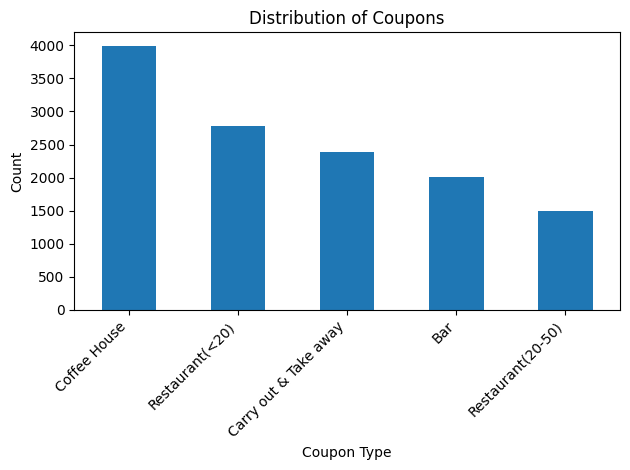

In [7]:

data['coupon'].value_counts().plot(kind='bar')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Distribution of Coupons')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("images/coupon.png")
plt.show()



6. Use a histogram to visualize the temperature column.

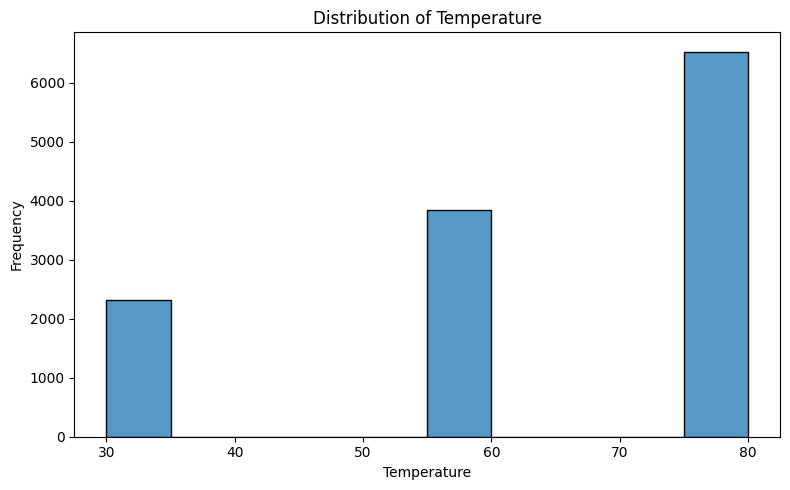

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='temperature', bins=10)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.tight_layout()
plt.savefig("images/temperature-histplot-def-bins.png")
plt.show()


Bar plot with fewer bins(3 buckets)

[55 80 30]


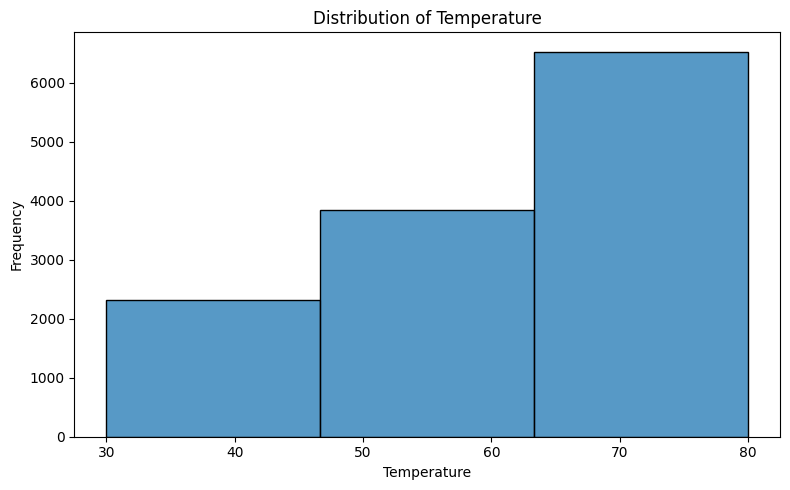

In [9]:
#Temperature column typically has a handful of distinct values (30, 55, 80),
#so we might actually get cleaner-looking bars with fewer bins 3
print(data['temperature'].unique())
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='temperature', bins=3)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.tight_layout()
plt.savefig("images/temperature-less-bins-histplot.png")
plt.show()


Bar plot vs histogram

temperature
30    2316
55    3840
80    6528
Name: count, dtype: int64


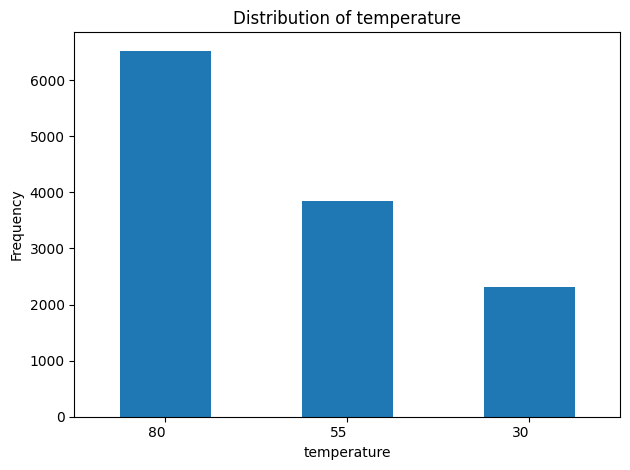

In [10]:
# The temperature column has only a few discrete values (just 30, 55, and 80).
#If that is the case then a bar plot is actually better than a histogram.
print(data['temperature'].value_counts().sort_index())
data['temperature'].value_counts().plot(kind='bar')
plt.xlabel('temperature')
plt.ylabel('Frequency')
plt.title('Distribution of temperature')
plt.xticks(rotation=360, ha='right')
plt.tight_layout()
plt.savefig("images/temperature-barplot.png")
plt.show()


Plot to compare Y values for each coupon type

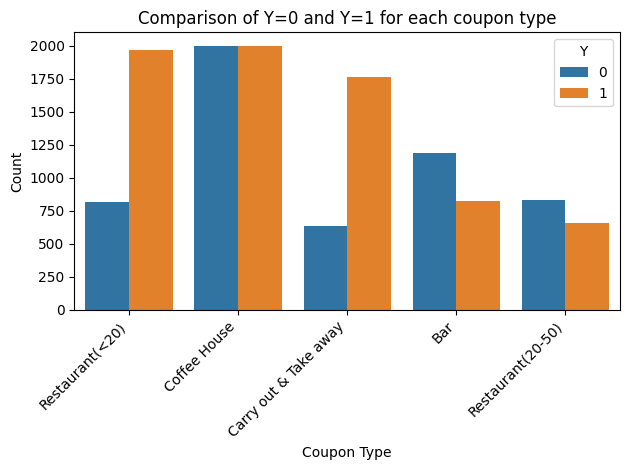

In [11]:
sns.countplot(x='coupon', hue = 'Y', data = data)
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Comparison of Y=0 and Y=1 for each coupon type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("images/coupon-countplot.png")
plt.show()


Plot to just Compare the Y values of 0 and 1

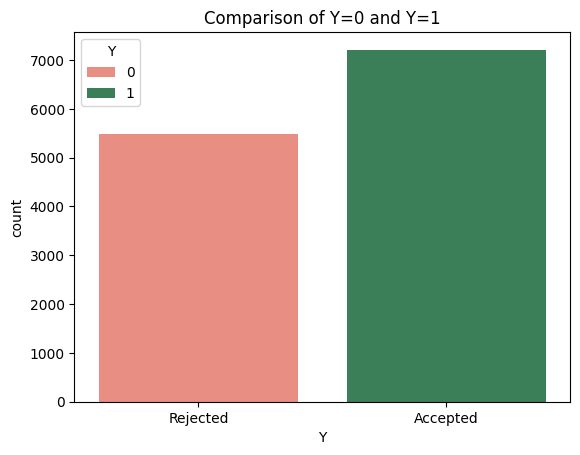

In [12]:
sns.countplot(x='Y', hue='Y', data = data, palette=['salmon', 'seagreen'])
plt.title('Comparison of Y=0 and Y=1')
plt.xticks([0, 1], ['Rejected', 'Accepted'], rotation=0)
plt.savefig("images/compare-y-values.png")
plt.show()




**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
bar_coupon_data = None
#copy is used to avoid the warning SettingWithCopyWarning:
#A value is trying to be set on a copy of a slice from a DataFrame.

bar_coupon_data = data[data['coupon'] == 'Bar' ].copy()
bar_coupon_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [14]:
print(bar_coupon_data['Y'].value_counts())
#Since Y is 0/1, .mean() directly returns that proportion.
print(f"bar coupon acceptance rate: {bar_coupon_data['Y'].mean():.1%}")

Y
0    1190
1     827
Name: count, dtype: int64
bar coupon acceptance rate: 41.0%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [15]:
# Check the actual categories first
print(bar_coupon_data['Bar'].unique())
# Define the two groups
low_freq = ['never', 'less1', '1~3']
high_freq = ['4~8', 'gt8']

bar_coupon_data['bar_freq_group'] = bar_coupon_data['Bar'].apply(
    lambda x: '3 or fewer' if x in low_freq else ('more than 3' if x in high_freq else None)
)

# Compare the acceptance rates
acceptance_by_group = bar_coupon_data.groupby('bar_freq_group')['Y'].mean()
print(acceptance_by_group.apply(lambda x: f"{x:.1%}"))

['never' 'less1' '1~3' 'gt8' nan '4~8']
bar_freq_group
3 or fewer     37.1%
more than 3    76.9%
Name: Y, dtype: object


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [16]:
# Check the actual age categories first
print(data['age'].unique())
# Define the "more than once a month" bar-visit group
frequent_bar = ['1~3', '4~8', 'gt8']

# Handle age: map to a numeric-ish comparison
# 'below21' -> exclude, '50plus' -> include, everything else compare directly
def is_over_25(age_val):
    if age_val == 'below21':
        return False
    if age_val == '50plus':
        return True
    return int(age_val) > 25

data['over_25'] = data['age'].apply(is_over_25)
data['frequent_bar_goer'] = data['Bar'].isin(frequent_bar)

# Define the target group vs. everyone else
data['group'] = data.apply(
    lambda row: 'frequent bar + over 25' if row['frequent_bar_goer'] and row['over_25'] else 'all others',
    axis=1
)
# Compare acceptance rates
acceptance_by_group = data.groupby('group')['Y'].mean()
print(acceptance_by_group.apply(lambda x: f"{x:.1%}"))

rate_a = acceptance_by_group['frequent bar + over 25']
rate_b = acceptance_by_group['all others']

diff = rate_a - rate_b
print(f"Difference: {diff:.1%}")

['21' '46' '26' '31' '41' '50plus' '36' 'below21']
group
all others                55.4%
frequent bar + over 25    62.2%
Name: Y, dtype: object
Difference: 6.8%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [17]:
# Check the actual category values first
print(data['passanger'].unique())
print(data['occupation'].unique())

frequent_bar = ['1~3', '4~8', 'gt8']

# Boolean condition combining all three criteria
target_condition = (
    data['Bar'].isin(frequent_bar) &
    (data['passanger'] != 'Kid(s)') &
    (data['occupation'] != 'Farming Fishing & Forestry')
)

# Create the grouping column directly from the boolean mask
data['group3'] = target_condition.map({True: 'target group', False: 'all others'})

# Groupby and compare
acceptance_by_group3 = data.groupby('group3')['Y'].mean()
print(acceptance_by_group3.apply(lambda x: f"{x:.1%}"))

# Difference in percentage points
rate_a = acceptance_by_group3['target group']
rate_b = acceptance_by_group3['all others']
print(f"Difference: {(rate_a - rate_b):.1%}")

['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 'Transportation & Material Moving'
 'Business & Financial' 'Protective Service'
 'Food Preparation & Serving Related' 'Production Occupations'
 'Building & Grounds Cleaning & Maintenance' 'Farming Fishing & Forestry']
group3
all others      54.6%
target group    62.3%
Name: Y, dtype: object
Difference: 7.7%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [18]:
# Check the relevant category values first
print(data['maritalStatus'].unique())
print(data['age'].unique())
print(data['income'].unique())
print(data['RestaurantLessThan20'].unique())

frequent_bar = ['1~3', '4~8', 'gt8']
frequent_cheap_resto = ['4~8', 'gt8']  # more than 4 times a month

# Condition 1: frequent bar + passenger not a kid + not widowed
cond1 = (
    data['Bar'].isin(frequent_bar) &
    (data['passanger'] != 'Kid(s)') &
    (data['maritalStatus'] != 'Widowed')
)

# Condition 2: frequent bar + under 30
# age is stored as strings; 'below21' and numeric strings under 30 all qualify
under_30_ages = ['below21', '21', '26']
cond2 = (
    data['Bar'].isin(frequent_bar) &
    data['age'].isin(under_30_ages)
)

# Condition 3: cheap restaurant >4x/month + income < 50K
under_50k_incomes = [
    'Less than $12500', '$12500 - $24999',
    '$25000 - $37499', '$37500 - $49999'
]
cond3 = (
    data['RestaurantLessThan20'].isin(frequent_cheap_resto) &
    data['income'].isin(under_50k_incomes)
)

# Combine with OR
target_condition = cond1 | cond2 | cond3
data['group4'] = target_condition.map({True: 'target group', False: 'all others'})
acceptance_by_group4 = data.groupby('group4')['Y'].agg(['mean', 'count'])
print(acceptance_by_group4)

['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
['21' '46' '26' '31' '41' '50plus' '36' 'below21']
['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']
['4~8' '1~3' 'less1' 'gt8' nan 'never']
                  mean  count
group4                       
all others    0.543149   7532
target group  0.605396   5152


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Acceptance isn't random across the population — it climbs steadily as behavioral (bar frequency), situational (who's in the car), and demographic (age) factors align together. No single factor fully explains acceptance on its own; it's the combination that produces the highest acceptance probability.

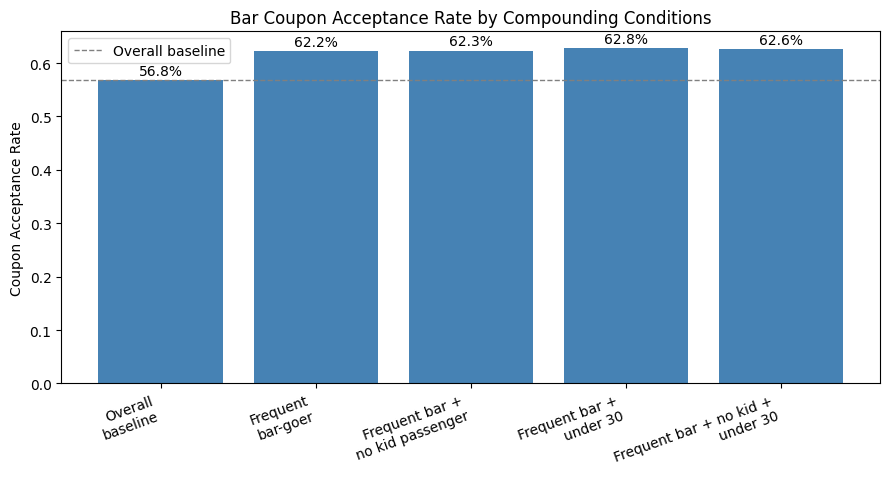

In [19]:
# Collect the acceptance rate for each condition tested, plus baseline
summary = {
    'Overall\nbaseline': data['Y'].mean(),
    'Frequent\nbar-goer': data.loc[data['Bar'].isin(['1~3','4~8','gt8']), 'Y'].mean(),
    'Frequent bar +\nno kid passenger': data.loc[
        data['Bar'].isin(['1~3','4~8','gt8']) & (data['passanger'] != 'Kid(s)'), 'Y'
    ].mean(),
    'Frequent bar +\nunder 30': data.loc[
        data['Bar'].isin(['1~3','4~8','gt8']) & data['age'].isin(['below21','21','26']), 'Y'
    ].mean(),
    'Frequent bar + no kid +\nunder 30': data.loc[
        data['Bar'].isin(['1~3','4~8','gt8']) &
        (data['passanger'] != 'Kid(s)') &
        data['age'].isin(['below21','21','26']), 'Y'
    ].mean(),
}

plt.figure(figsize=(9, 5))
bars = plt.bar(summary.keys(), summary.values(), color='steelblue')
plt.axhline(data['Y'].mean(), color='gray', linestyle='--', linewidth=1, label='Overall baseline')
plt.ylabel('Coupon Acceptance Rate')
plt.title('Bar Coupon Acceptance Rate by Compounding Conditions')
plt.xticks(rotation=20, ha='right')

# Label each bar with its percentage
for bar, val in zip(bars, summary.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.1%}", ha='center')

plt.legend()
plt.tight_layout()
plt.savefig("images/bar-coupon-compound-cond-barplot.png")
plt.show()


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

1. Create a new DataFrame that contains just the bar coupons.

In [20]:
coffe_house_coupon_data = data[data['coupon'] == 'Coffee House'].copy()
coffe_house_coupon_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,over_25,frequent_bar_goer,group,group3,group4
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,0,0,0,1,0,False,False,all others,all others,target group
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,1,0,0,1,0,False,False,all others,all others,target group
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,1,0,0,1,0,False,False,all others,all others,target group
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,1,0,0,1,1,False,False,all others,all others,target group
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,0,0,0,1,0,False,False,all others,all others,target group
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,1,0,0,1,0,True,False,all others,all others,all others
12659,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,0,0,1,0,0,True,False,all others,all others,all others
12674,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,0,0,1,0,0,True,False,all others,all others,all others
12675,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,1,0,0,1,0,True,False,all others,all others,all others


2. What proportion of Coffee House coupons were accepted?

In [21]:
print(coffe_house_coupon_data['Y'].value_counts())
#Since Y is 0/1, .mean() directly returns that proportion.
print(f"Coffee House coupon acceptance rate: {coffe_house_coupon_data['Y'].mean():.1%}")

Y
0    2001
1    1995
Name: count, dtype: int64
Coffee House coupon acceptance rate: 49.9%


3. Acceptance rate by age > 30

In [22]:
acceptance_by_age_gt30 = coffe_house_coupon_data.groupby(coffe_house_coupon_data['age'] > '30')['Y'].agg(['mean', 'count'])
print(acceptance_by_age_gt30.sort_values('mean', ascending=False))

           mean  count
age                   
False  0.519699   1726
True   0.483700   2270


Plot the proportion of CoffeeHouse Coupon Type accepted by passanger

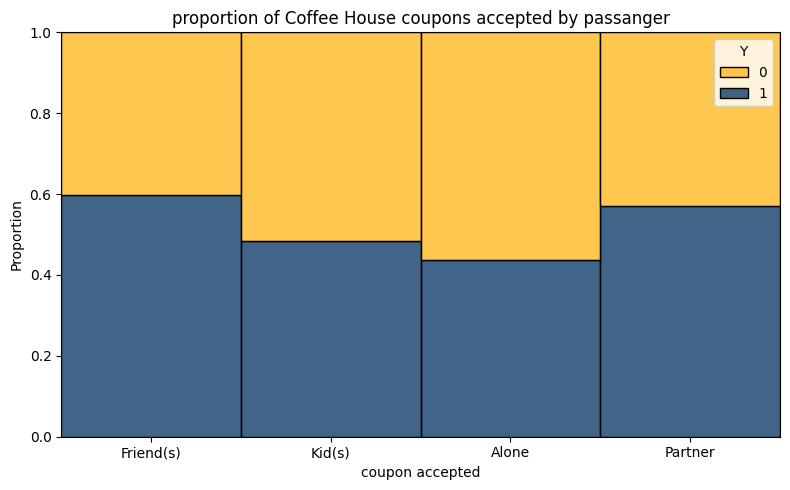

In [23]:
NAVY = "#003262"
GOLD = "#FDB515"
PALETTE = [NAVY, GOLD, "#3B7EA1", "#C4820E"]

plt.figure(figsize=(8, 5))
sns.histplot(data=coffe_house_coupon_data, x="passanger", hue="Y", multiple="fill",
             palette=[GOLD, NAVY],bins=4)
plt.title("proportion of Coffee House coupons accepted by passanger")
plt.xlabel("coupon accepted")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("images/coffee-house-coupon-accepted.png")
plt.show()


Combine frequency and a situational factor with passanger not a kid

In [24]:
frequent_coffee = ['1~3', '4~8', 'gt8']
print(f"sum of frequent_coffee: {coffe_house_coupon_data['CoffeeHouse'].isin(frequent_coffee).sum()}")
print(f"sum of passanger not kids: {(coffe_house_coupon_data['passanger'] != 'Kid(s)').sum()}")

cond = (
    coffe_house_coupon_data['CoffeeHouse'].isin(frequent_coffee) &
    (coffe_house_coupon_data['passanger'] != 'Kid(s)')
)
print(f"sum of coffeehouse and passanger condition: {cond.sum()}")
coffe_house_coupon_data['group'] = cond.map({True: 'frequent + no kid', False: 'all others'})

print(coffe_house_coupon_data.groupby('group')['Y'].agg(['mean', 'count']))

sum of frequent_coffee: 1922
sum of passanger not kids: 3789
sum of coffeehouse and passanger condition: 1813
                       mean  count
group                             
all others         0.365094   2183
frequent + no kid  0.660783   1813


Comparison of Y values(0 and 1) with CoffeeHouse column

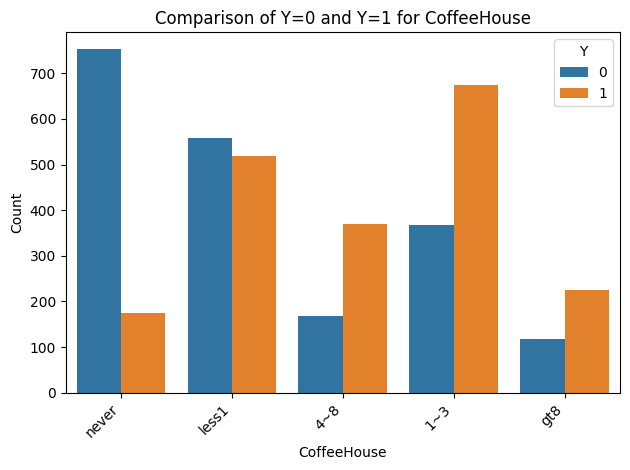

In [25]:
sns.countplot(x='CoffeeHouse', hue = 'Y', data = coffe_house_coupon_data)
plt.xlabel('CoffeeHouse')
plt.ylabel('Count')
plt.title('Comparison of Y=0 and Y=1 for CoffeeHouse')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("images/coffeehouse-countplot.png")
plt.show()
